# Model-Independent P(k) Reconstruction: Fisher Information Decomposition
## DESI Y6 Configuration (7 skies, 6 unique redshifts)

This notebook demonstrates how constraints on cosmological parameters from galaxy clustering
can be decomposed into contributions from:
1. **P(k) amplitudes** (h-independent at high z) → constrains $[\omega_{\rm cdm}, A_s]$
2. **Growth factors** with h-encoding → constrains $[\omega_{\rm cdm}, h]$

### Key approach:
- **P(k) parametrization**: Store P_lin amplitudes at knots in **Mpc³** (units: 1/Mpc) at high reference z (z_ref=10)
  - At z_ref, P(k) is naturally h-independent in the matter-dominated regime
  - Amplitudes are stored relative to fiducial (fiducial = 1.0)
  - When feeding to PyBird, convert back to **(Mpc/h)³** using h_conv parameter
- **Growth parametrization**: Store as **[f, H/H₀, D_A×H₀, D_ratios, h_conv]**
  - f, H, DA depend on Omega_m = omega_m/h² (physics)
  - h_conv is the unit conversion parameter (identity Jacobian: h_conv = h)
- The h-dependence is encoded in growth factors which break the Ω_m degeneracy

We show that: $F_{\rm cosmo}^{\rm direct} \approx F_{\rm cosmo}^{P(k)} + F_{\rm cosmo}^{\rm growth}$


note we are using AP shifts so that there is BAO growth factor information


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import yaml
import jax
import jax.numpy as jnp
from getdist import MCSamples, plots

jax.config.update("jax_enable_x64", True)

from pybird import config
config.set_jax_enabled(True)
from pybird.module import *
from pybird.likelihood import Likelihood
from pybird.fake import Fake

# Import CosmoPower-JAX for P(k) emulation at high redshift
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# Plot styling
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.figsize'] = (10, 6)


jax: on


## 1. Setup: Fiducial Cosmology and Data Configuration


In [2]:
# Fiducial cosmology (this is the TRUE cosmology we want to recover)
cosmo_fid = {
    'omega_b': 0.02235,
    'omega_cdm': 0.120,
    'h': 0.675,
    'ln10^{10}A_s': 3.044,
    'n_s': 0.965
}

# =============================================================================
# h_fid: Offset from true h to encode h-dependence in growth sector -> now using this also for conversion to and from mpc units!
# =============================================================================
h_fid = cosmo_fid['h'] * 1.1  # 10% offset
print(f"h_true = {cosmo_fid['h']}, h_fid = {h_fid:.4f}")

# =============================================================================
# Reference redshift: HIGH z where P_lin is h-independent
# Using z_ref=5.0 (CosmoPower-JAX supports z up to 5)
# =============================================================================
z_ref = 5.0  # High z - P_lin in Mpc³ is nearly h-independent here
print(f"Reference z for P_lin: z_ref = {z_ref}")

# =============================================================================
# Unit conversion functions (Mpc³ ↔ (Mpc/h)³)
# Using PURE JAX (jnp.interp) for full differentiability
# =============================================================================
def to_Mpc(pk_mpc_h, kk_mpc_h, h, kk_out_mpc=None):
    """Convert P(k) from (Mpc/h)³ to Mpc³ (numpy version)."""
    if kk_out_mpc is None:
        kk_out_mpc = kk_mpc_h / h
    log_pk = np.interp(np.log(kk_out_mpc), np.log(kk_mpc_h / h), np.log(pk_mpc_h))
    return np.exp(log_pk) / h**3

def to_Mpc_per_h(pk_mpc, kk_mpc, h, kk_out_mpc_h=None):
    """Convert P(k) from Mpc³ to (Mpc/h)³ (numpy version)."""
    if kk_out_mpc_h is None:
        kk_out_mpc_h = kk_mpc * h
    log_pk = np.interp(np.log(kk_out_mpc_h * h), np.log(kk_mpc), np.log(pk_mpc))
    return np.exp(log_pk) * h**3

# JAX versions - PURE JAX for differentiability
def to_Mpc_jax(pk_mpc_h, kk_mpc_h, h, kk_out_mpc):
    """Convert P(k) from (Mpc/h)³ to Mpc³ (pure JAX, fully differentiable)."""
    # Interpolate in log-space for numerical stability
    log_pk = jnp.interp(
        jnp.log(kk_out_mpc / h),   # target k in log (1/Mpc -> h/Mpc)
        jnp.log(kk_mpc_h),          # source k in log (h/Mpc)
        jnp.log(pk_mpc_h)           # source P(k) in log
    )
    return jnp.exp(log_pk) / h**3

def to_Mpc_per_h_jax(pk_mpc, kk_mpc, h, kk_out_mpc_h):
    """Convert P(k) from Mpc³ to (Mpc/h)³ (pure JAX, fully differentiable)."""
    # Interpolate in log-space for numerical stability
    log_pk = jnp.interp(
        jnp.log(kk_out_mpc_h * h),  # target k in log (h/Mpc -> 1/Mpc)
        jnp.log(kk_mpc),            # source k in log (1/Mpc)
        jnp.log(pk_mpc)             # source P(k) in log
    )
    return jnp.exp(log_pk) * h**3

# =============================================================================
# DESI Y6 Survey Configuration: 7 skies at 6 unique redshifts
# =============================================================================
DESI_Y6 = {
    'n_sky': 7, 
    'zmin': [.1, .4, .6, .8, .8, 1.1, .8],
    'zmax': [.4, .6, .8, 1.1, 1.1, 1.6, 2.1],
    'zeff': [0.295, 0.51, 0.706, 0.930, 0.930, 1.317, 1.491],
    'Veff': np.array([4., 8., 12., 15., 8., 12., 4.])*1.e9,  # Mpc^3
    'degsq': [14000]*7, 
    'P0': np.array([9.2, 8.9, 8.9, 8.4, 8.4, 2.9, 5.])*1.e3,  # (Mpc/h)^3
    'nbar_prior': [3.e-4, 3.e-4, 3.e-4, 3.e-4, 3.e-4, 2.e-3, 1.e-4],
}

num_skies = DESI_Y6['n_sky']
zmin_list = DESI_Y6['zmin']
zmax_list = DESI_Y6['zmax']
zeff_list = DESI_Y6['zeff']
Veff_list = DESI_Y6['Veff']
degsq_list = DESI_Y6['degsq']
P0_list = DESI_Y6['P0']
nbar_prior_list = DESI_Y6['nbar_prior']

# Get unique redshifts for growth parameters
zeff_unique = sorted(list(set(zeff_list)))
n_z_unique = len(zeff_unique)
print(f"\nDESI Y6: {num_skies} skies, {n_z_unique} unique redshifts")
print(f"Unique z_eff: {zeff_unique}")

# k-range in h/Mpc (for PyBird) and 1/Mpc (for Mpc³ P_lin)
k_l, k_r = 1e-4, 0.7
kk_h = np.logspace(np.log10(k_l), np.log10(k_r), 500)  # k in h/Mpc
kk_mpc = kk_h / h_fid  # k in 1/Mpc

# =============================================================================
# Initialize CosmoPower-JAX emulator for P(k)
# =============================================================================
cpj_pklin = CPJ(probe='mpk_lin')
cpj_k_modes = jnp.array(cpj_pklin.modes)  # k in 1/Mpc (CPJ native units - NOT h/Mpc!)

def pklin_cpj(k_mpc, omega_b, omega_cdm, h, lnAs, n_s, z):
    """
    JAX-differentiable P_lin using CosmoPower-JAX.
    
    IMPORTANT: CPJ uses pure Mpc units internally:
      - k modes are in 1/Mpc (NOT h/Mpc)
      - P(k) output is in Mpc³ (NOT (Mpc/h)³)
    
    This function outputs pk in Mpc^3 
    
    Args:
        k_h: wavenumbers in 1/Mpc
        omega_b, omega_cdm: physical densities
        h, lnAs, n_s: cosmological params
        z: redshift (scalar)
    
    Returns:
        P_lin in (Mpc/h)³ at requested k values (PyBird convention)
    """
    input_dict = {
        'omega_b': jnp.atleast_1d(omega_b),
        'omega_cdm': jnp.atleast_1d(omega_cdm),
        'h': jnp.atleast_1d(h),
        'ln10^{10}A_s': jnp.atleast_1d(lnAs),
        'n_s': jnp.atleast_1d(n_s),
        'z': jnp.atleast_1d(z)
    }
    pk_cpj_mpc = cpj_pklin.predict(input_dict)  # P(k) in Mpc³ at cpj_k_modes (1/Mpc)
    
    
    # Interpolate in log-space for numerical stability onto the grid of k_mpc
    log_pk_out = jnp.interp(jnp.log(k_mpc), jnp.log(cpj_k_modes), jnp.log(pk_cpj_mpc))
    pk_mpc = jnp.exp(log_pk_out)  # P(k) in Mpc³
    return pk_mpc

print(f"\nCosmoPower-JAX initialized:")
print(f"  k-modes range: [{cpj_k_modes.min():.4f}, {cpj_k_modes.max():.4f}] 1/Mpc")
print(f"  Number of k-modes: {len(cpj_k_modes)}")

# Test CPJ at fiducial cosmology and z_ref
pk_test = pklin_cpj(
    jnp.array([0.1]),  # k = 0.1 1/Mpc
    cosmo_fid['omega_b'], 
    cosmo_fid['omega_cdm'],
    cosmo_fid['h'],
    cosmo_fid['ln10^{10}A_s'],
    cosmo_fid['n_s'],
    z_ref
)
print(f"  Test P(k=0.1 1/Mpc, z={z_ref}): {float(pk_test[0]):.2e} (Mpc)³")

# Compute fiducial cosmology with Symbolic for growth factors (still needed)
from pybird.symbolic import Symbolic
M_sym = Symbolic()
M_sym.set(cosmo_fid)

# Compute at z_ref for growth factor reference
M_sym.compute(kk_h, z_ref)
D_ref = M_sym.D  # Growth factor at z_ref
Omega0_m = M_sym.c['Omega_m']

print(f"\nFiducial cosmology: omega_cdm = {cosmo_fid['omega_cdm']}, h = {cosmo_fid['h']}")
print(f"Omega_m = {Omega0_m:.4f}")
print(f"D(z_ref={z_ref}) = {D_ref:.6f}")

# Compute fiducial growth at each unique DESI redshift
D1_fid = {}    # Growth factor D(z)
f_fid = {}     # Growth rate f(z)
H_fid = {}     # H(z)/H_0
DA_fid = {}    # D_A(z)*H_0

print(f"\nGrowth factors at each unique redshift (with h_fid scaling):")
print("-"*70)
print(f"{'z':>6} {'f':>8} {'H/H0':>8} {'DA*H0':>8} {'D':>8} | {'(H/H0)*h_fid':>12} {'(DA*H0)*h_fid':>14}")
print("-"*70)

for z in zeff_unique:
    M_sym.compute(kk_h, z)
    D1_fid[z] = M_sym.D
    f_fid[z] = M_sym.f
    H_fid[z] = M_sym.H  # THE SYMBOLIC FUNCTION ALREADY GIVES YOU H(z)/H_0
    DA_fid[z] = M_sym.DA  # THE SYMBOLIC FUNCTION ALREADY GIVES YOU D_A(z)*H_0
    
    H_scaled = H_fid[z] * h_fid
    DA_scaled = DA_fid[z] * h_fid
    print(f"{z:>6.3f} {f_fid[z]:>8.4f} {H_fid[z]:>8.4f} {DA_fid[z]:>8.4f} {D1_fid[z]:>8.4f} | {H_scaled:>12.4f} {DA_scaled:>14.4f}")


h_true = 0.675, h_fid = 0.7425
Reference z for P_lin: z_ref = 5.0

DESI Y6: 7 skies, 6 unique redshifts
Unique z_eff: [0.295, 0.51, 0.706, 0.93, 1.317, 1.491]

CosmoPower-JAX initialized:
  k-modes range: [0.0000, 9.8099] 1/Mpc
  Number of k-modes: 420
  Test P(k=0.1 1/Mpc, z=5.0): 4.81e+02 (Mpc)³

Fiducial cosmology: omega_cdm = 0.12, h = 0.675
Omega_m = 0.3124
D(z_ref=5.0) = 0.211678

Growth factors at each unique redshift (with h_fid scaling):
----------------------------------------------------------------------
     z        f     H/H0    DA*H0        D | (H/H0)*h_fid  (DA*H0)*h_fid
----------------------------------------------------------------------
 0.295   0.6804   1.1688   0.2115   0.8557 |       0.8678         0.1570
 0.510   0.7624   1.3279   0.2958   0.7659 |       0.9859         0.2196
 0.706   0.8178   1.4963   0.3434   0.6954 |       1.1110         0.2550
 0.930   0.8638   1.7128   0.3761   0.6269 |       1.2717         0.2792
 1.317   0.9144   2.1386   0.4006   0.5327

## 1b. Generate Fake DESI Y6 Data

We generate theoretical (noiseless) data at the fiducial cosmology using the DESI Y6 configuration (7 skies, 6 unique redshifts). The likelihood at the fiducial should give χ² = 0.


In [3]:
# Use template config from existing DESI Y6 setup
rootdir = "../" 



fakedir = os.path.join(rootdir, 'data', 'fake')
fakeconfigdir = os.path.join(fakedir, 'likelihood_config')
template_configfile = os.path.join(fakeconfigdir, 'fake_fast_pk_desi_y6.yaml')

# Output paths for this analysis
output_path = os.path.join(rootdir, "output")
fake_data_name = 'fake_desi_y6_fisher'
fake_config_name = 'fake_desi_y6_fisher_config'

print("Generating fake DESI Y6 data...")
print(f"Template config: {template_configfile}")

s = DESI_Y6
F = Fake(
    s['n_sky'], s['zmin'], s['zmax'], s['zeff'], s['Veff'], s['degsq'], s['P0'], 
    cosmo_fid, 
    likelihood_config_template_file=template_configfile, 
    boltzmann='CPJ',
    Omega_m_fid=Omega0_m, 
    kmin=0.01, kmax=0.2, dk=0.01, 
    nbar_prior=s['nbar_prior'],
    fake_data_filename=fake_data_name, 
    path_to_data=output_path, 
    fake_likelihood_config_filename=fake_config_name, 
    path_to_config=output_path
)

# Generate fake data
F.set()

# Get fiducial EFT params from Fake class
fiducial_nuisance = F.fiducial_nuisance[0]  # Same for all skies
print(f"\nFiducial EFT: {fiducial_nuisance}")
print("Fake DESI Y6 data generated!")


Generating fake DESI Y6 data...
Template config: ../data/fake/likelihood_config/fake_fast_pk_desi_y6.yaml
jax: on
No fiducial EFT parameters specified, using default ones
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0

In [4]:
# Load the generated fake likelihood config
fake_config_path = os.path.join(output_path, f'{fake_config_name}.yaml')
lkl_config = yaml.full_load(open(fake_config_path))

lkl_config['get_maxlkl'] = True 
print(f"Set drop_logdet = True to ensure chi2 = 0 at fiducial")

# Initialize likelihood with fake data
L_jax = Likelihood(lkl_config)

# Test that fiducial gives log-likelihood = 0 (chi2 = 0)
eft_fid_flat = np.array([fiducial_nuisance['b1'], fiducial_nuisance['b2'], fiducial_nuisance['b4']] * num_skies)
eft_names_flat = ['b1', 'b2', 'b4'] * num_skies

# Create a k-array compatible with the fake data (k: 0.001 to 0.35)
# Use a simple logspace that covers the needed range without being too large
kk_lkl = jnp.logspace(np.log10(0.0001), np.log10(1), 500)

# Build cosmo_dict for each sky at fiducial using Symbolic
cosmo_dict_fid = []
for i_sky in range(num_skies):
    z = zeff_list[i_sky]
    M_sym.compute(kk_lkl, z)
    pklin_mpc = pklin_cpj(
    jnp.array(kk_lkl*cosmo_fid["h"]), 
    cosmo_fid['omega_b'], 
    cosmo_fid['omega_cdm'],
    cosmo_fid['h'],
    cosmo_fid['ln10^{10}A_s'],
    cosmo_fid['n_s'],
    z
    )
    pklin_h = to_Mpc_per_h_jax(pklin_mpc, jnp.array(kk_lkl*cosmo_fid["h"]), cosmo_fid["h"], kk_lkl)
    cosmo_dict_fid.append({
        "H": float(M_sym.H),     # H(z)/H_0 - convert to Python float
        "DA": float(M_sym.DA),   # D_A(z)*H_0 - convert to Python float
        "pk_lin": pklin_h,
        "kk": kk_lkl,
        "f": float(M_sym.f)      # f(z) - convert to Python float
    })

lkl_at_fid = L_jax.loglkl(eft_fid_flat, eft_names_flat, 
                          need_cosmo_update=True, cosmo_dict=cosmo_dict_fid,
                          cosmo_module=None, cosmo_engine=None)
chi2_at_fid = -2 * float(lkl_at_fid)

print(f"\n{'='*50}")
print("SANITY CHECK: Likelihood at fiducial cosmology")
print(f"{'='*50}")
print(f"Log-likelihood at fiducial: {float(lkl_at_fid):.6f}")
print(f"Chi-squared at fiducial:    {chi2_at_fid:.6f}")
print(f"Expected (for theory data): 0.0")
print(f"{'='*50}")

if np.abs(chi2_at_fid) < 0.01:
    print("✓ SUCCESS: Chi-squared is essentially zero!")
else:
    print("⚠ WARNING: Chi-squared is not zero - check the setup!")


Set drop_logdet = True to ensure chi2 = 0 at fiducial
reading data file: ../output/fake_desi_y6_fisher.h5
-----------------------
sky: sky_1
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
-----------------------
sky: sky_2
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
-----------------------
sky: sky_3
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
-----------------------
sky: sky_4
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
-----------------------
sky: sky_5
output: bPk
multipole: 3
min bound (per mul

## 2. Load Optimized Knots and Setup P(k) Parametrization



P_lin at z_ref=5.0 (computed with CosmoPower-JAX):
  Number of knots: 38 (4 low-k buffer + 20 main)
  k range: [0.0050, 0.350] h/Mpc
  Main range: [0.03, 0.35] h/Mpc (where information lives)
  P(k) range: [9.81e+01, 3.63e+03] Mpc³
  Note: Stored in Mpc³ (1/Mpc units), converted to (Mpc/h)³ for PyBird
  Using z_ref=5.0 for better h-independence than z_ref=3


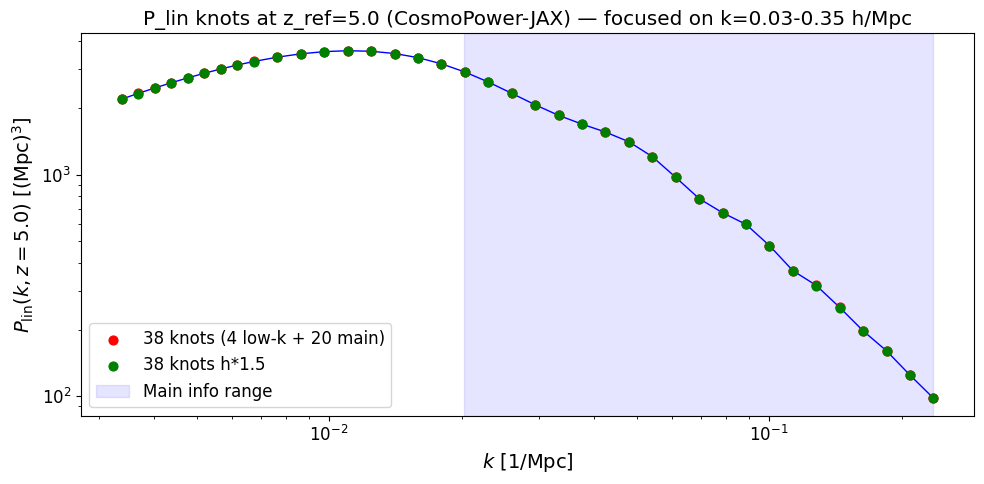

In [5]:
# =============================================================================
# IMPORTANT: Use CosmoPower-JAX to compute fiducial P(k) at z_ref=5
# This provides accurate P(k) at higher redshift than Symbolic (limited to z=3)
# =============================================================================
from pybird.symbolic import D

# =============================================================================
# Knots for P_lin parametrization
# Focus on k range where P(k) carries information: ~0.03-0.35 h/Mpc
# A few knots on the low-k side for interpolation stability, but most in 0.03-0.35
# =============================================================================
# Low-k buffer knots (sparse, just for interpolation boundary)
k_low = np.logspace(np.log10(0.005), np.log10(0.01), 8, endpoint=False)  # 4 knots below 0.03
# Main information-carrying range
k_main = np.logspace(np.log10(0.01), np.log10(0.35), 30)  # 20 knots in 0.03-0.35

knots_h = np.concatenate([k_low, k_main])  # total ~24 knots
n_knots = len(knots_h)
knots_h_jax = jnp.array(knots_h)

# Convert knots to 1/Mpc for Mpc³ storage: knots (1/Mpc) = knots_h (h/Mpc) * h
knots_mpc = knots_h * cosmo_fid['h']  # k in 1/Mpc
# these are the knots at which we will learn the pk 

knots_mpc_jax = jnp.array(knots_mpc)

# =============================================================================
# Fiducial P(k) at knots using CosmoPower-JAX
# Store in Mpc³ (units: 1/Mpc) at z_ref for h-independence
# At z_ref=5, P(k) in Mpc³ should have minimal h-dependence
# =============================================================================

# Compute fiducial P(k) at z_ref using CPJ
pk_at_knots = pklin_cpj(
    knots_mpc_jax,
    cosmo_fid['omega_b'],
    cosmo_fid['omega_cdm'],
    cosmo_fid['h'],
    cosmo_fid['ln10^{10}A_s'],
    cosmo_fid['n_s'],
    z_ref
)


pk_at_knots2 = pklin_cpj(
    knots_mpc_jax,
    cosmo_fid['omega_b'],
    cosmo_fid['omega_cdm'],
    cosmo_fid['h']*1.1,
    cosmo_fid['ln10^{10}A_s'],
    cosmo_fid['n_s'],
    z_ref
)

pk_at_knots_jax = jnp.array(pk_at_knots)

print(f"\nP_lin at z_ref={z_ref} (computed with CosmoPower-JAX):")
print(f"  Number of knots: {n_knots} (4 low-k buffer + 20 main)")
print(f"  k range: [{knots_h.min():.4f}, {knots_h.max():.3f}] h/Mpc")
print(f"  Main range: [0.03, 0.35] h/Mpc (where information lives)")
print(f"  P(k) range: [{float(pk_at_knots.min()):.2e}, {float(pk_at_knots.max()):.2e}] Mpc³")
print(f"  Note: Stored in Mpc³ (1/Mpc units), converted to (Mpc/h)³ for PyBird")
print(f"  Using z_ref={z_ref} for better h-independence than z_ref=3")

# Visualize knot positions
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(np.array(knots_mpc), np.array(pk_at_knots), 'b-', lw=1)
ax.scatter(np.array(knots_mpc), np.array(pk_at_knots), c='red', s=40, zorder=5, label=f'{n_knots} knots (4 low-k + 20 main)')
ax.scatter(np.array(knots_mpc), np.array(pk_at_knots2), c='green', s=40, zorder=5, label=f'{n_knots} knots h*1.5')

# Mark the main information range
k_main_mpc = np.array([0.03, 0.35]) * cosmo_fid['h']
ax.axvspan(k_main_mpc[0], k_main_mpc[1], alpha=0.1, color='blue', label='Main info range')

ax.set_xlabel(r'$k$ [1/Mpc]')
ax.set_ylabel(r'$P_{\rm lin}(k, z=' + str(z_ref) + r')$ [(Mpc)$^3$]')
ax.legend()
ax.set_title(f'P_lin knots at z_ref={z_ref} (CosmoPower-JAX) — focused on k=0.03-0.35 h/Mpc')
plt.tight_layout()

### confirm that there is negligible h information here  

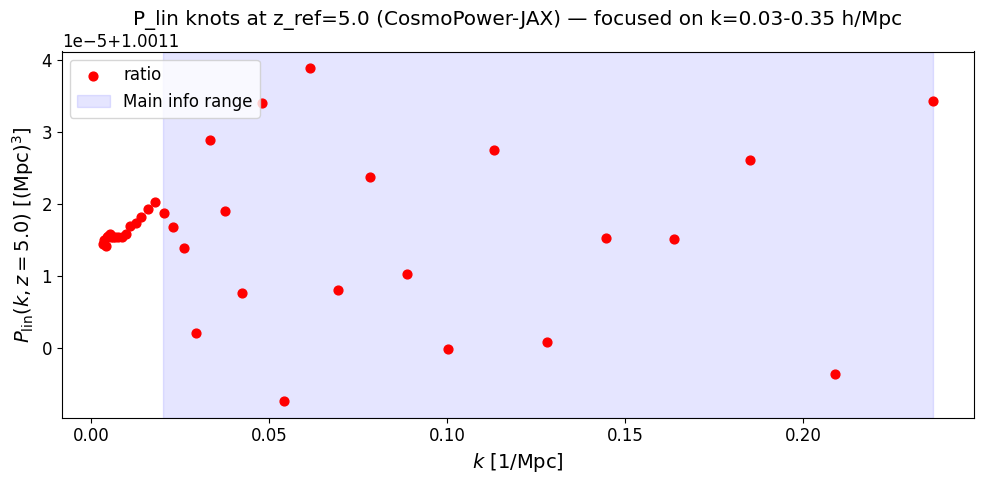

In [6]:
# Visualize knot positions
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(np.array(knots_mpc), np.array(pk_at_knots)/np.array(pk_at_knots2), c='red', s=40, zorder=5, label='ratio')
# Mark the main information range
k_main_mpc = np.array([0.03, 0.35]) * cosmo_fid['h']
ax.axvspan(k_main_mpc[0], k_main_mpc[1], alpha=0.1, color='blue', label='Main info range')

ax.set_xlabel(r'$k$ [1/Mpc]')
ax.set_ylabel(r'$P_{\rm lin}(k, z=' + str(z_ref) + r')$ [(Mpc)$^3$]')
ax.legend()
ax.set_title(f'P_lin knots at z_ref={z_ref} (CosmoPower-JAX) — focused on k=0.03-0.35 h/Mpc')
plt.tight_layout()

In [7]:
# EFT parameters for 7 DESI skies - use the fiducial values from fake data generation
eft_free_names = ["b1", "b2", "b4"]  # Free EFT parameters

# Use the same EFT values as fiducial_nuisance (same for all skies)
eft_init = np.array([fiducial_nuisance[key] for _ in range(num_skies) for key in eft_free_names])
eft_param_names = [f"{key}_{i+1}" for i in range(num_skies) for key in eft_free_names]

print(f"DESI Y6 configuration: {num_skies} skies")
print(f"Free EFT parameters per sky: {eft_free_names}")
print(f"Total free EFT parameters: {len(eft_init)}")
print(f"EFT init values (first 9): {eft_init[:9]} ...")

# NOTE: We use L_jax from cell 6 (fake data likelihood) - DO NOT reload here!

DESI Y6 configuration: 7 skies
Free EFT parameters per sky: ['b1', 'b2', 'b4']
Total free EFT parameters: 21
EFT init values (first 9): [1.9542 0.4173 0.4173 1.9542 0.4173 0.4173 1.9542 0.4173 0.4173] ...


In [8]:

growth_fid_list = []
growth_names = []

# knots_mpc is already defined in cell 8 (k in 1/Mpc)
# Use it consistently - do NOT redefine here!
print(f"Number of knots: {n_knots}")
print(f"k range: [{knots_h.min():.4f}, {knots_h.max():.3f}] h/Mpc")
print(f"k range (1/Mpc): [{knots_mpc.min():.4f}, {knots_mpc.max():.3f}] 1/Mpc")

print("="*70)
print("NEW PARAMETRIZATION: Growth = [f, H/H0, DA*H0, D_ratios, h_conv]")
print("  - f, H, DA: depend on Omega_m = omega_m/h² (physics)")
print("  - h_conv: direct parameter for unit conversion (identity Jacobian)")
print("="*70)


# f, H/H0, DA*H0 at each unique redshift (NOT scaled by h)
for z in zeff_unique:
    growth_fid_list.extend([f_fid[z], H_fid[z]*cosmo_fid["h"]/h_fid, DA_fid[z]*h_fid/cosmo_fid["h"]])
    growth_names.extend([f'f(z={z:.2f})', f'H/H0(z={z:.2f})', f'DA*H0(z={z:.2f})'])
    print(f"z={z:.3f}: f={f_fid[z]:.4f}, H/H0={H_fid[z]:.4f}, DA*H0={DA_fid[z]:.4f}")

# Growth ratios D(z)/D(z_ref) for ALL z (z_ref=10, where P(k) is stored)
print("-"*70)
print(f"D ratios relative to z_ref={z_ref}:")
for z in zeff_unique:
    ratio = D1_fid[z] / D_ref
    growth_fid_list.append(ratio)
    growth_names.append(f'D(z={z:.2f})/D(z_ref)')
    print(f"D(z={z:.3f})/D(z_ref={z_ref}) = {ratio:.4f}")

# h_conv: the unit conversion parameter (equals h at fiducial)
# h_conv_fid = cosmo_fid['h']
# growth_fid_list.append(h_conv_fid)
# growth_names.append('h_conv')
# print("-"*70)
# print(f"h_conv (unit conversion): {h_conv_fid:.4f}")

growth_fid = np.array(growth_fid_list)
n_growth = len(growth_fid)

# =============================================================================
# Build full fiducial parameter vector
# =============================================================================
pk_amps_fid = np.ones(n_knots)  # Relative amplitudes = 1 at fiducial
params_fid = np.concatenate([eft_init, pk_amps_fid, growth_fid])

print(f"\n{'='*70}")
print(f"Total parameters: {len(params_fid)}")
print(f"  - EFT: {len(eft_init)} (3 per sky x {num_skies} skies)")
print(f"  - P(k) knots: {n_knots} (amplitudes)")
print(f"  - Growth: {n_growth} ({n_z_unique} z x 3 params + {n_z_unique} D-ratios + 1 h_conv)")


Number of knots: 38
k range: [0.0050, 0.350] h/Mpc
k range (1/Mpc): [0.0034, 0.236] 1/Mpc
NEW PARAMETRIZATION: Growth = [f, H/H0, DA*H0, D_ratios, h_conv]
  - f, H, DA: depend on Omega_m = omega_m/h² (physics)
  - h_conv: direct parameter for unit conversion (identity Jacobian)
z=0.295: f=0.6804, H/H0=1.1688, DA*H0=0.2115
z=0.510: f=0.7624, H/H0=1.3279, DA*H0=0.2958
z=0.706: f=0.8178, H/H0=1.4963, DA*H0=0.3434
z=0.930: f=0.8638, H/H0=1.7128, DA*H0=0.3761
z=1.317: f=0.9144, H/H0=2.1386, DA*H0=0.4006
z=1.491: f=0.9294, H/H0=2.3488, DA*H0=0.4038
----------------------------------------------------------------------
D ratios relative to z_ref=5.0:
D(z=0.295)/D(z_ref=5.0) = 4.0422
D(z=0.510)/D(z_ref=5.0) = 3.6180
D(z=0.706)/D(z_ref=5.0) = 3.2854
D(z=0.930)/D(z_ref=5.0) = 2.9615
D(z=1.317)/D(z_ref=5.0) = 2.5167
D(z=1.491)/D(z_ref=5.0) = 2.3542

Total parameters: 83
  - EFT: 21 (3 per sky x 7 skies)
  - P(k) knots: 38 (amplitudes)
  - Growth: 24 (6 z x 3 params + 6 D-ratios + 1 h_conv)


## 4. Model-Independent Likelihood Function


In [36]:
# Map each sky to its unique redshift index
sky_to_z_idx = [zeff_unique.index(z) for z in zeff_list]
print(f"Sky to unique z index mapping: {sky_to_z_idx}")

# Growth parameters layout:
# - For each unique z: [f, H/H0, DA*H0] (NOT scaled by h)
# - Then D-ratios: D(z)/D(z_ref) for each unique z
# - Finally: h_conv (unit conversion parameter)
n_growth_per_z = 3  # f, H/H0, DA*H0
n_growth_ratios = n_z_unique  # D(z)/D(z_ref=10) for ALL z
n_growth = n_z_unique * n_growth_per_z + n_growth_ratios #+ 1  # +1 for h_conv

print(f"Growth parameters: {n_z_unique} x 3 (f, H/H0, DA*H0) + {n_growth_ratios} D-ratios + 1 h_conv = {n_growth}")

def model_independent_loglkl(params):
    """
    Model-independent log-likelihood for DESI Y6.
    
    PARAMETRIZATION:
    - EFT parameters (21 = 3 per sky x 7 skies)
    - P(k) amplitudes at knots (relative to fiducial at z_ref=10)
      * Stored in Mpc³ (1/Mpc units) for h-independence
      * Converted to (Mpc/h)³ using h_conv when feeding to PyBird
    - Growth parameters: [f_z, H/H0_z, DA*H0_z for each z, D_ratios, h_conv]
      * h_conv: unit conversion parameter (h_conv = h, identity Jacobian)
    
    The likelihood interpolates P(k) from knots to data k-values internally.
    """
    n_eft = len(eft_init)
    
    # Extract parameters
    eft_params = params[:n_eft]
    pk_amps = params[n_eft:n_eft + n_knots]  # Relative amplitudes (fiducial = 1.0)
    growth_params = params[n_eft + n_knots:]
    
    # Extract growth factors
    f_z = []
    H_over_H0 = []
    DA_times_H0 = []
    
    for i_z in range(n_z_unique):
        idx = i_z * n_growth_per_z
        f_z.append(growth_params[idx])
        H_over_H0.append(growth_params[idx + 1])
        DA_times_H0.append(growth_params[idx + 2])
    
    # D(z)/D(z_ref) ratios
    ratio_start_idx = n_z_unique * n_growth_per_z
    D_ratios = []
    for i in range(n_z_unique):
        D_ratios.append(growth_params[ratio_start_idx + i])
    
    # h_conv: unit conversion parameter (h_conv = h)
    # h_conv = growth_params[-1]

    h_conv = h_fid 
    
    # Reconstruct P(k) at knots: pk_amps * fiducial (in Mpc³)
    pk_knots_mpc = pk_amps * pk_at_knots_jax  # Still in Mpc³
    
    # Convert from Mpc³ to (Mpc/h)³ for PyBird using h_conv
    # to_Mpc_per_h_jax(pk_mpc, kk_mpc, h, kk_out_mpc_h)
    knots_h_jax = knots_mpc_jax/h_conv
    pk_knots_h = to_Mpc_per_h_jax(pk_knots_mpc, knots_mpc_jax, h_conv, knots_h_jax)

    
    # ==========================================================================
    # Build cosmology dictionaries for each sky]
    # ==========================================================================
    cosmo_list_dict = []
    for i_sky in range(num_skies):
        i_z = sky_to_z_idx[i_sky]
        
        # Scale P(k) from z_ref to this sky's redshift using D_ratio²
        D_ratio = D_ratios[i_z]
        pk_input = pk_knots_h * D_ratio**2  # P(k) in (Mpc/h)³ at this z
        
        cosmo_list_dict.append({
            "H": H_over_H0[i_z], 
            "DA": DA_times_H0[i_z], 
            "pk_lin": pk_input,  # P(k) in (Mpc/h)³
            "kk": knots_h_jax,   # k in h/Mpc (likelihood interpolates to data k-values)
            "f": f_z[i_z]
        })
    
    # Compute likelihood
    lkl = L_jax.loglkl(eft_params, eft_free_names * num_skies, 
                       need_cosmo_update=True, cosmo_dict=cosmo_list_dict,
                       cosmo_module=None, cosmo_engine=None)

    #THIS IS AN ASSUMPTION WE SHOULD REVISIT! 
    # add a gaussian term over the pk amps to stop them going too craazy when they are unconstraints - this is very important for numerical stability 
    sigma = 0.5
    gauss_lkl = -0.5*jnp.sum((pk_amps-jnp.ones_like(pk_amps))**2/sigma**2)

    # sigma_growth = 0.2 # Start wide (50% uncertainty) to avoid biasing the result
    # growth_prior = -0.5 * jnp.sum((growth_params - growth_fid)**2 / sigma_growth**2)
    
    return lkl + gauss_lkl

# JIT compile
model_independent_loglkl_jit = jax.jit(model_independent_loglkl)


Sky to unique z index mapping: [0, 1, 2, 3, 3, 4, 5]
Growth parameters: 6 x 3 (f, H/H0, DA*H0) + 6 D-ratios + 1 h_conv = 24


In [37]:
# =============================================================================
# Build fiducial growth parameter vector
# NEW APPROACH: [f, H, DA] (NOT scaled by h) + D_ratios + h_conv
# h_conv is a direct observable that equals h (identity Jacobian element)
# =============================================================================
# =============================================================================
# Build full fiducial parameter vector
# =============================================================================
pk_amps_fid = np.ones(n_knots)  # Relative amplitudes = 1 at fiducial
params_fid = np.concatenate([eft_init, pk_amps_fid, growth_fid])

print(f"\n{'='*70}")
print(f"Total parameters: {len(params_fid)}")
print(f"  - EFT: {len(eft_init)} (3 per sky x {num_skies} skies)")
print(f"  - P(k) knots: {n_knots} (amplitudes)")
print(f"  - Growth: {n_growth} ({n_z_unique} z x 3 params + {n_z_unique} D-ratios + 1 h_conv)")

# Test likelihood
print("\nTesting model_independent_loglkl...")
lkl_test = model_independent_loglkl(jnp.array(params_fid))
print(f"Fiducial log-likelihood: {lkl_test}")
print(f"Chi² at fiducial: {-2*float(lkl_test):.4f} (should be ~0)")



Total parameters: 83
  - EFT: 21 (3 per sky x 7 skies)
  - P(k) knots: 38 (amplitudes)
  - Growth: 24 (6 z x 3 params + 6 D-ratios + 1 h_conv)

Testing model_independent_loglkl...
Fiducial log-likelihood: -4.115404656882183
Chi² at fiducial: 8.2308 (should be ~0)


## 5. Compute Full Fisher Matrix and Extract Sub-blocks


In [38]:
# Compute Hessian (negative = Fisher matrix)
print("Computing Fisher matrix for model-independent parametrization...")
hessian_fn = jax.hessian(model_independent_loglkl)
F_full = -hessian_fn(jnp.array(params_fid))
F_full = np.array(F_full)

print(f"Fisher matrix shape: {F_full.shape}")

# Define parameter blocks
n_eft = len(eft_init)
idx_eft = np.arange(0, n_eft)
idx_pk = np.arange(n_eft, n_eft + n_knots)
idx_growth = np.arange(n_eft + n_knots, len(params_fid))

print(f"EFT indices: 0-{n_eft-1}")
print(f"P(k) indices: {n_eft}-{n_eft + n_knots - 1}")
print(f"Growth indices: {n_eft + n_knots}-{len(params_fid) - 1}")


Computing Fisher matrix for model-independent parametrization...
Fisher matrix shape: (83, 83)
EFT indices: 0-20
P(k) indices: 21-58
Growth indices: 59-82


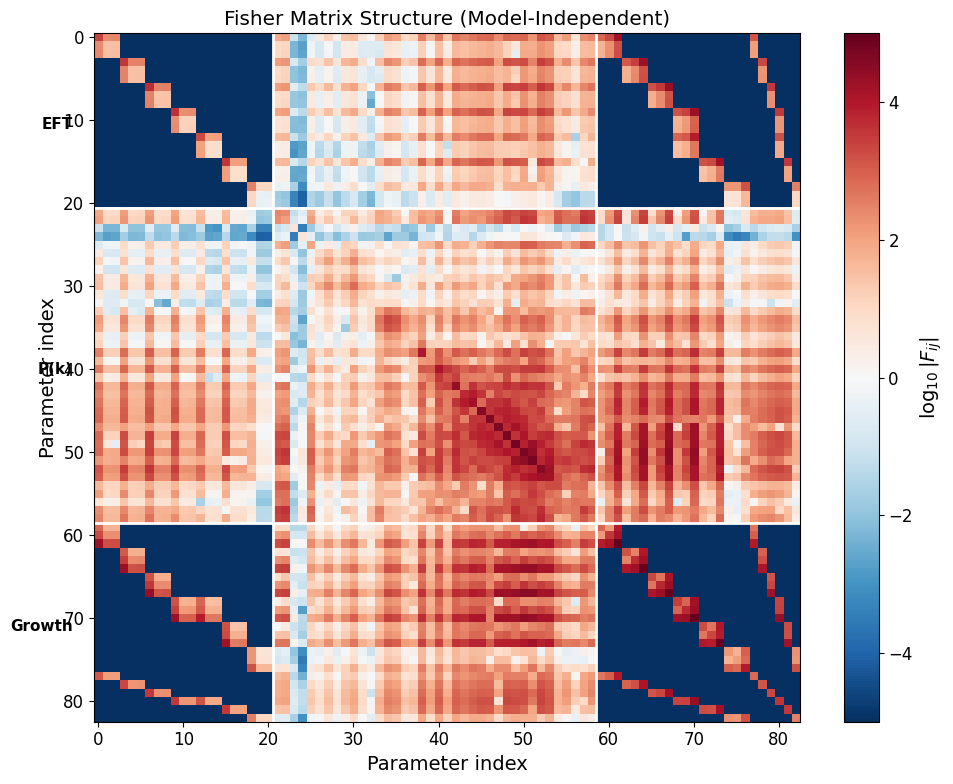

In [39]:
# Visualize Fisher matrix structure
fig, ax = plt.subplots(figsize=(10, 8))

F_viz = np.log10(np.abs(F_full) + 1e-10)
im = ax.imshow(F_viz, cmap='RdBu_r', aspect='auto', vmin=-5, vmax=5)

# Add block boundaries
boundaries = [0, n_eft, n_eft + n_knots, len(params_fid)]
labels = ['EFT', 'P(k)', 'Growth']

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color='white', lw=2)
    ax.axvline(b - 0.5, color='white', lw=2)

plt.colorbar(im, label=r'$\log_{10}|F_{ij}|$')
ax.set_title('Fisher Matrix Structure (Model-Independent)')
ax.set_xlabel('Parameter index')
ax.set_ylabel('Parameter index')

# Add labels
for i, (b1, b2, label) in enumerate(zip(boundaries[:-1], boundaries[1:], labels)):
    mid = (b1 + b2) / 2
    ax.text(-3, mid, label, ha='right', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()


In [40]:
np.linalg.eigvals(F_full)

array([ 3.15917882e+05,  2.80396776e+05,  2.70726345e+05,  2.64091034e+05,
        1.45328319e+05,  7.50030293e+04,  6.70124901e+04,  5.63756676e+04,
        4.83319786e+04,  4.43620639e+04,  3.79395762e+04,  2.90951661e+04,
        2.45681253e+04,  1.68782048e+04,  1.22503986e+04,  9.79286584e+03,
       -7.01810056e+03,  7.86870691e+03,  6.32812772e+03,  5.57885457e+03,
        5.26509728e+03,  4.51012451e+03,  3.73109384e+03,  3.16047693e+03,
        3.01457175e+03,  2.84468189e+03,  2.55392292e+03,  2.39056719e+03,
        1.81870013e+03,  1.71845763e+03, -1.28918454e+03,  1.26165611e+03,
        1.01198529e+03,  9.76820193e+02,  8.69952682e+02,  7.03965135e+02,
        6.32092175e+02,  5.31210113e+02,  3.45816738e+02,  3.22104291e+02,
        1.90791761e+02,  1.81277318e+02, -1.25001760e+02,  9.61020686e+01,
        7.40350118e+01,  5.40107409e+01, -2.70005546e+01,  2.77109729e+01,
        2.28636469e+01, -1.15574737e+01,  1.26836950e+01,  1.09905087e+01,
        1.07046231e+01, -

In [41]:
def pos_pinv(F, rtol=1e-15):
    """Pseudoinverse restricted to positive eigenvalues.
    Prevents Schur complement from subtracting spurious information when F has
    near-zero eigenvalues that turn slightly negative from floating-point noise."""
    F = 0.5*(F+F.T); w,V = np.linalg.eigh(F)
    scale = float(np.abs(w).max()) or 1.0
    w_inv = np.where(w > rtol*scale, 1.0/w, 0.0)
    return (V*w_inv)@V.T

# Use pos_pinv (not np.linalg.inv) to handle near-zero eigenvalues from EFT params
F_full_inv = np.linalg.inv(F_full)

In [42]:
# =============================================================================
# Utility functions for stable Fisher arithmetic
# (pos_pinv defined in previous cell — reused here)
# =============================================================================

# =============================================================================
# Marginalize over EFT parameters via Schur complement
# Use pos_pinv for EFT block inverse (EFT params can be poorly constrained)
# =============================================================================
F_eft_eft   = F_full[np.ix_(idx_eft, idx_eft)]
idx_phys    = np.concatenate([idx_pk, idx_growth])
F_phys_phys = F_full[np.ix_(idx_phys, idx_phys)]
F_phys_eft  = F_full[np.ix_(idx_phys, idx_eft)]
F_eft_phys  = F_full[np.ix_(idx_eft, idx_phys)]

F_eft_inv   = np.linalg.inv(F_eft_eft)
F_phys_marg = F_phys_phys - F_phys_eft @ F_eft_inv @ F_eft_phys

print(f"F_phys_marg shape: {F_phys_marg.shape}")
eigs_pm = np.linalg.eigvalsh(F_phys_marg)
print(f"F_phys_marg: min_eig={eigs_pm.min():.2e}, max_eig={eigs_pm.max():.2e}")
if eigs_pm.min() < 0:
    print(f"  Note: {np.sum(eigs_pm<0)} tiny negative eigenvalues "
          f"(rel={eigs_pm.min()/eigs_pm.max():.1e}) — floating-point noise, harmless")

F_pk_block     = F_phys_marg[:n_knots, :n_knots]
F_growth_block = F_phys_marg[n_knots:, n_knots:]
F_cross_block  = F_phys_marg[:n_knots, n_knots:]
print(f"F_pk block: {F_pk_block.shape},  F_growth block: {F_growth_block.shape}")

F_phys_marg shape: (62, 62)
F_phys_marg: min_eig=-7.10e+03, max_eig=2.08e+05
  Note: 12 tiny negative eigenvalues (rel=-3.4e-02) — floating-point noise, harmless
F_pk block: (38, 38),  F_growth block: (24, 24)


## 6. P(k) Posterior from Fisher (marginalized over growth)


Condition numbers: F_pk=6.00e+04, F_growth=3.88e+06
F_growth_block: min_eig=-2.47e+00, max_eig=1.63e+05


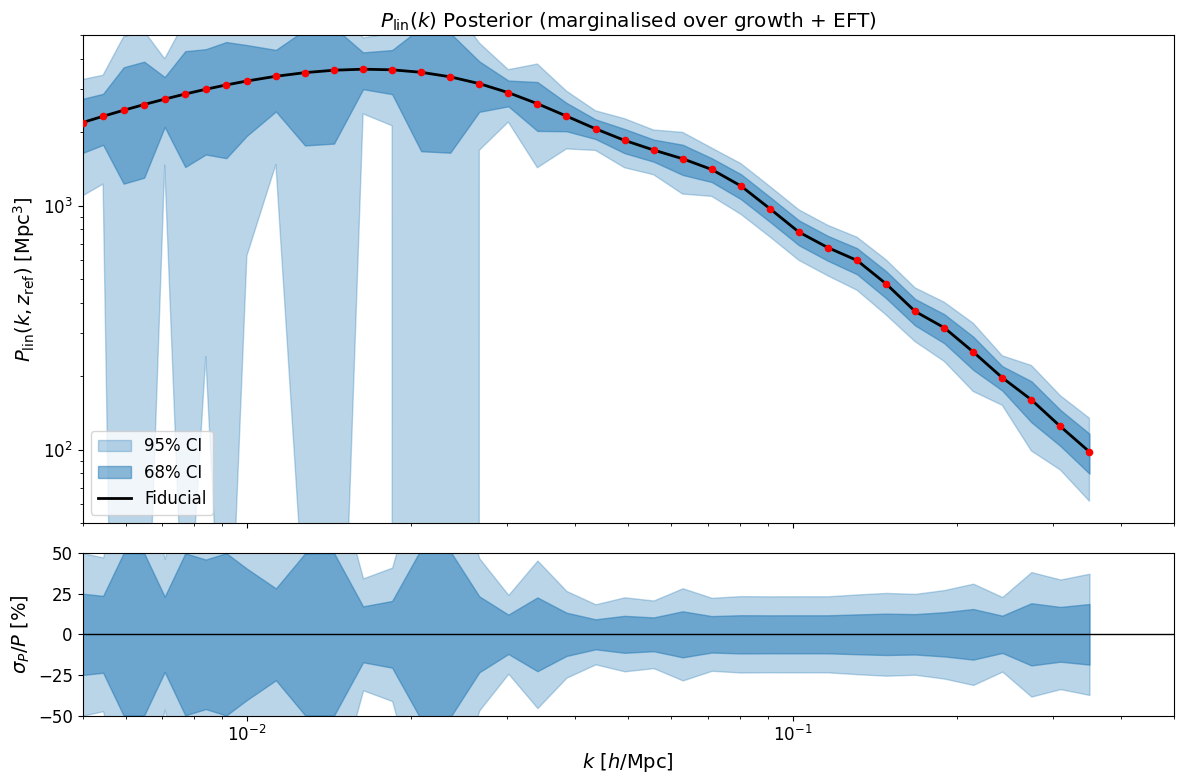

In [43]:
# =============================================================================
# Marginalize over growth → F_pk_marginal  (Schur complement within F_phys_marg)
#
# OLD approach: np.linalg.inv(F_full_inv[ix_pk, ix_pk])
#   — double inversion through the full matrix amplifies floating-point error
#
# NEW approach: Schur complement within F_phys_marg (EFT already marginalised)
#   F_pk|growth = F_pk_block - F_cross @ pos_pinv(F_growth_block) @ F_cross.T
#   pos_pinv discards near-zero eigenvalues of F_growth_block so the Schur
#   complement doesn't subtract a spurious negative-definite term.
# =============================================================================
cond_pk     = np.linalg.cond(F_pk_block)
cond_growth = np.linalg.cond(F_growth_block)
print(f"Condition numbers: F_pk={cond_pk:.2e}, F_growth={cond_growth:.2e}")

eigs_g = np.linalg.eigvalsh(F_growth_block)
print(f"F_growth_block: min_eig={eigs_g.min():.2e}, max_eig={eigs_g.max():.2e}")

idx_nuisance = np.concatenate([idx_eft, idx_growth]) # Combined nuisances
F_pp = F_full[np.ix_(idx_pk, idx_pk)]
F_nn = F_full[np.ix_(idx_nuisance, idx_nuisance)]
F_pn = F_full[np.ix_(idx_pk, idx_nuisance)]
F_np = F_full[np.ix_(idx_nuisance, idx_pk)]

# 3. Single Schur Complement
# Using pinv or a robust solver is safer if the nuisance block is poorly conditioned
intermediate = np.linalg.solve(F_nn, F_np) 
F_pk_marginal = F_pp - F_pn @ intermediate

# F_pk_marginal = F_pk_block - F_cross_block @ np.linalg.inv(F_growth_block) @ F_cross_block.T



sigma_pk = np.sqrt(np.diag(pos_pinv(F_pk_marginal)))

# Plot P(k) posterior
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax = axes[0]
pk_1sigma_upper = pk_at_knots * (1 + sigma_pk)
pk_1sigma_lower = pk_at_knots * (1 - sigma_pk)
pk_2sigma_upper = pk_at_knots * (1 + 2*sigma_pk)
pk_2sigma_lower = pk_at_knots * (1 - 2*sigma_pk)
ax.fill_between(knots_h, pk_2sigma_lower, pk_2sigma_upper, alpha=0.3, color='C0', label='95% CI')
ax.fill_between(knots_h, pk_1sigma_lower, pk_1sigma_upper, alpha=0.5, color='C0', label='68% CI')
ax.loglog(knots_h, pk_at_knots, 'k-', lw=2, label='Fiducial')
ax.scatter(knots_h, pk_at_knots, c='red', s=20, zorder=5)
ax.set_ylabel(r'$P_{\rm lin}(k, z_{\rm ref})$ [Mpc$^3$]')
ax.set_ylim(50, 5000)
ax.legend(loc='lower left')
ax.set_title(r'$P_{\rm lin}(k)$ Posterior (marginalised over growth + EFT)')
ax = axes[1]
ax.fill_between(knots_h, -2*sigma_pk*100, 2*sigma_pk*100, alpha=0.3, color='C0')
ax.fill_between(knots_h, -sigma_pk*100, sigma_pk*100, alpha=0.5, color='C0')
ax.axhline(0, color='k', lw=1)
ax.set_xlabel(r'$k$ [$h$/Mpc]')
ax.set_ylabel(r'$\sigma_P/P$ [%]')
ax.set_xscale('log')
ax.set_ylim(-50, 50)
ax.set_xlim(0.005, 0.5)
plt.tight_layout()

In [44]:
np.linalg.eigvalsh(F_pk_marginal)

array([-7.08242470e+03, -1.51389663e+03, -1.43695216e+02, -2.78626645e+01,
       -1.53998878e+01, -3.34443889e+00,  1.46895698e+00,  3.18667853e+00,
        3.67863388e+00,  3.97753138e+00,  3.99997331e+00,  4.00000000e+00,
        4.00000000e+00,  4.00000000e+00,  4.01710438e+00,  6.73212633e+00,
        9.24736895e+00,  1.11072833e+01,  2.45739970e+01,  6.35920446e+01,
        1.08642757e+02,  2.19924041e+02,  4.60005797e+02,  6.63786432e+02,
        1.29130758e+03,  2.12131796e+03,  4.83754656e+03,  5.91166843e+03,
        7.88969964e+03,  1.21185383e+04,  1.70614076e+04,  2.09758323e+04,
        2.81864289e+04,  3.47161234e+04,  4.28755157e+04,  4.56527311e+04,
        5.35237862e+04,  6.77996908e+04])

## 7. Growth Factor Posterior (marginalized over P(k))



Growth parameter constraints (marginalised over P(k) and EFT):
f(z=0.29)                               : 0.6804 +/- 0.2218  (32.6%)
H/H0(z=0.29)                            : 1.0625 +/- 0.0253  (2.4%)
DA*H0(z=0.29)                           : 0.2326 +/- 0.0013  (0.5%)
f(z=0.51)                               : 0.7624 +/- 0.1421  (18.6%)
H/H0(z=0.51)                            : 1.2072 +/- 0.0202  (1.7%)
DA*H0(z=0.51)                           : 0.3254 +/- 0.0017  (0.5%)
f(z=0.71)                               : 0.8178 +/- 0.1384  (16.9%)
H/H0(z=0.71)                            : 1.3603 +/- 0.0176  (1.3%)
DA*H0(z=0.71)                           : 0.3777 +/- 0.0022  (0.6%)
f(z=0.93)                               : 0.8638 +/- 0.1684  (19.5%)
H/H0(z=0.93)                            : 1.5571 +/- 0.0172  (1.1%)
DA*H0(z=0.93)                           : 0.4137 +/- 0.0020  (0.5%)
f(z=1.32)                               : 0.9144 +/- 0.3336  (36.5%)
H/H0(z=1.32)                            : 1.944

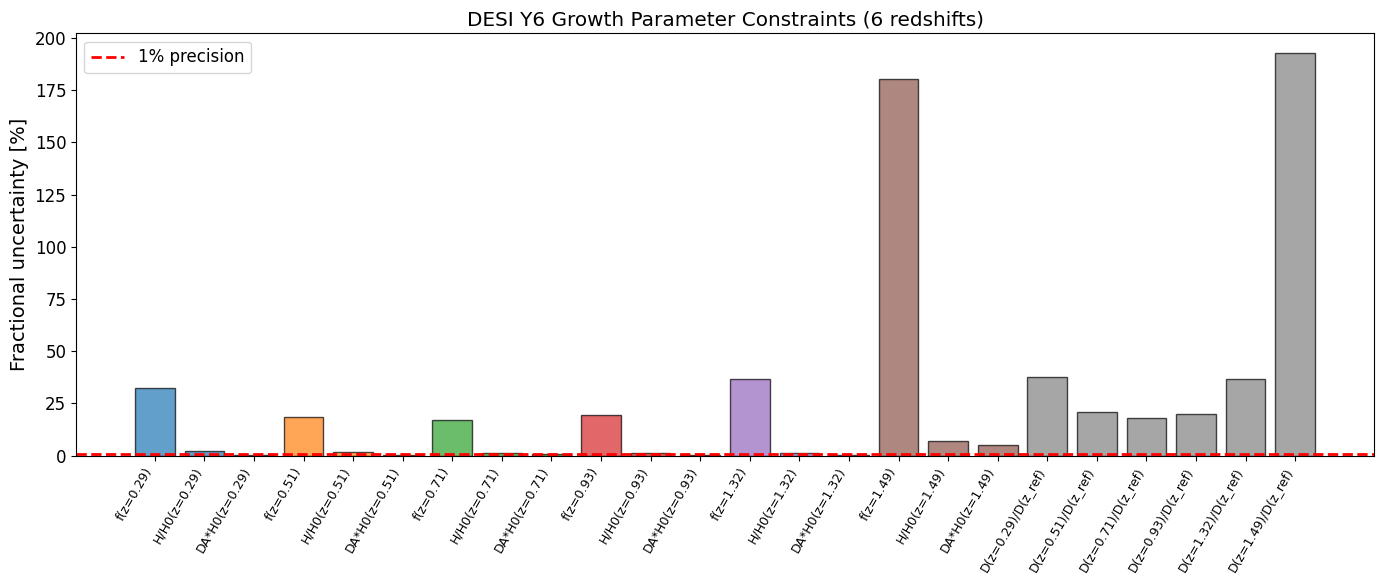

In [45]:
# =============================================================================
# Marginalize over P(k) → F_growth_marginal  (Schur complement within F_phys_marg)
#
# F_growth|pk = F_growth_block - F_cross.T @ pos_pinv(F_pk_block) @ F_cross
# pos_pinv handles any near-zero eigenvalues in F_pk_block gracefully.
# =============================================================================
idx_nuisance = np.concatenate([idx_pk, idx_eft]) # Combined nuisances (PK + EFT)

# 2. Slice the full matrix
F_gg = F_full[np.ix_(idx_growth, idx_growth)]
F_nn = F_full[np.ix_(idx_nuisance, idx_nuisance)]
F_gn = F_full[np.ix_(idx_growth, idx_nuisance)]
F_ng = F_full[np.ix_(idx_nuisance, idx_growth)]

intermediate = np.linalg.solve(F_nn, F_ng)
F_growth_marginal = F_gg - F_gn @ intermediate

cov_growth   = np.linalg.inv(F_growth_marginal)
sigma_growth = np.sqrt(np.abs(np.diag(cov_growth)))

print("\nGrowth parameter constraints (marginalised over P(k) and EFT):")
print("="*70)
for name, fid, sig in zip(growth_names, growth_fid, sigma_growth):
    print(f"{name:40s}: {fid:.4f} +/- {sig:.4f}  ({100*sig/abs(fid+1e-10):.1f}%)")

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(growth_names))
colors_bar = [f'C{i//3}' for i in range(n_z_unique*3)]
colors_bar += ['gray'] * n_growth_ratios + ['purple']
ax.bar(x, sigma_growth/np.abs(growth_fid + 1e-10) * 100,
       color=colors_bar[:len(growth_names)], alpha=0.7, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(growth_names, rotation=60, ha='right', fontsize=9)
ax.set_ylabel('Fractional uncertainty [%]')
ax.set_title(f'DESI Y6 Growth Parameter Constraints ({n_z_unique} redshifts)')
ax.axhline(1, color='red', ls='--', lw=2, label='1% precision')
ax.legend()
plt.tight_layout()

In [46]:
np.linalg.eigvalsh(F_growth_marginal)

array([-2.28778427e+03, -3.08851252e+00, -2.41130938e+00, -1.67703667e+00,
       -1.01731629e+00, -4.21099141e-01, -4.27559134e-02,  3.31101916e+01,
        6.09661978e+01,  1.16599863e+02,  3.99613141e+02,  7.42342737e+02,
        9.14175820e+02,  1.21952425e+03,  1.54285158e+03,  1.96061712e+03,
        2.34920606e+03,  2.95644257e+03,  3.33350040e+03,  9.44677523e+03,
        7.69692101e+04,  1.35624125e+05,  1.47432687e+05,  1.57866116e+05])

## 8. Mapping Back to Cosmological Parameters

Now we set up the mapping from (P(k), growth) → cosmology using emulators, and compute how the Fisher information projects onto cosmological parameters.


In [47]:
# Use Symbolic class for fully differentiable mapping from cosmology to observables
from pybird.symbolic import Symbolic, D, f, Hubble, DA
from pybird.symbolic_pofk_linear import plin_emulated

# Initialize Symbolic - this is JAX-differentiable!
sym = Symbolic(max_precision=False, smooth_de=True)

# Test that it works at the reference redshift
test_cosmo = {
    'omega_b': cosmo_fid['omega_b'],
    'omega_cdm': cosmo_fid['omega_cdm'],
    'h': cosmo_fid['h'],
    'ln10^{10}A_s': cosmo_fid['ln10^{10}A_s'],
    'n_s': cosmo_fid['n_s']
}
sym.set(test_cosmo)
sym.compute(jnp.array(knots_h), z_ref)  # Use knots_h and z_ref
print(f"Symbolic P(k) test at z={z_ref} - first 5 values: {sym.pk_lin[:5]}")
print(f"Symbolic growth at z={z_ref}: f={sym.f:.4f}, H={sym.H:.4f}, DA={sym.DA:.4f}")
print(f"  with h_fid={h_fid:.4f}: (H/H0)×h_fid={sym.H*h_fid:.4f}, (DA×H0)×h_fid={sym.DA*h_fid:.4f}")

print("\nSymbolic class loaded for differentiable mapping!")


Symbolic P(k) test at z=5.0 - first 5 values: [677.2244411  718.31185108 759.96742859 801.85631591 843.58925565]
Symbolic growth at z=5.0: f=0.9936, H=8.2566, DA=0.2987
  with h_fid=0.7425: (H/H0)×h_fid=6.1306, (DA×H0)×h_fid=0.2218

Symbolic class loaded for differentiable mapping!


In [48]:
# =============================================================================
# Mappings: cosmological parameters -> model-independent observables
# =============================================================================

zeff_unique_jax = jnp.array(zeff_unique)

def cosmo_to_pk(cosmo_params_3d):
    """
    Map cosmo params to P(k) amplitude ratios at fixed k[1/Mpc] grid.

    Returns: pk_mpc / pk_at_knots  (amplitude ratios relative to fiducial)
    """
    omega_cdm, lnAs, h = cosmo_params_3d[0], cosmo_params_3d[1], cosmo_params_3d[2]
    # h is accepted but pklin_cpj at fixed k[1/Mpc] has negligible h sensitivity
    # -> J_pk[:, 2] ~= 0 (verified in cell 29 diagnostics)
    omega_b = cosmo_fid['omega_b']
    n_s = cosmo_fid['n_s']
    pk_mpc = pklin_cpj(knots_mpc_jax, omega_b, omega_cdm, h, lnAs, n_s, z_ref)
    amps = pk_mpc / pk_at_knots_jax

    return amps

def cosmo_to_growth(cosmo_params_2d):
    """
    Map [omega_cdm, h] -> growth parameters.
    A_s excluded: growth is identically independent of amplitude.

    Returns: [f, H/H0, DA*H0 per z, D(z)/D(z_ref) per z, h_conv]
    h_conv = h: unit conversion parameter (h/Mpc <-> 1/Mpc, h^3 amplitude)
    """
    omega_cdm, h = cosmo_params_2d[0], cosmo_params_2d[1]
    omega_b = cosmo_fid['omega_b']
    Omega_m = (omega_cdm + omega_b) / h**2

    growth_list = []
    D_values = []
    for z in zeff_unique:
        growth_list.extend([f(Omega_m, z, -1., 0.), Hubble(Omega_m, z, -1., 0.)*h/cosmo_fid["h"], DA(Omega_m, z, -1., 0.)*cosmo_fid["h"]/h])
        D_values.append(D(Omega_m, z, -1., 0.))

    D_ref_val = D(Omega_m, z_ref, -1., 0.)
    for Dz in D_values:
        growth_list.append(Dz / D_ref_val)

    #growth_list.append(h)  # h_conv: identity Jacobian element deprecated
    return jnp.array(growth_list)

def cosmo_to_observables(cosmo_params):
    """Full mapping [omega_cdm, A_s, h] -> [pk_amps, growth_params]."""
    pk_amps = cosmo_to_pk(cosmo_params)
    growth_params = cosmo_to_growth(jnp.array([cosmo_params[0], cosmo_params[2]]))
    return jnp.concatenate([pk_amps, growth_params])

# Fiducial vectors
cosmo_fid_vec = jnp.array([cosmo_fid['omega_cdm'], cosmo_fid['ln10^{10}A_s'], cosmo_fid['h']])
cosmo_fid_2d  = jnp.array([cosmo_fid['omega_cdm'], cosmo_fid['h']])

# Verify at fiducial
obs_fid = cosmo_to_observables(cosmo_fid_vec)
print(f"P(k) amplitudes at fiducial (should be ~1): min={float(obs_fid[:n_knots].min()):.6f}, max={float(obs_fid[:n_knots].max()):.6f}")
print(f"h_conv at fiducial (should = {cosmo_fid['h']}): {float(obs_fid[-1]):.4f}")

# =============================================================================
# Jacobians
# =============================================================================
print("\nComputing Jacobians...")
J_pk        = np.array(jax.jacobian(cosmo_to_pk)(cosmo_fid_vec))         # [n_knots x 3]
J_growth_2d = np.array(jax.jacobian(cosmo_to_growth)(cosmo_fid_2d))      # [n_growth x 2]
J_full      = np.array(jax.jacobian(cosmo_to_observables)(cosmo_fid_vec)) # [n_knots+n_growth x 3]
print(f"J_pk: {J_pk.shape},  J_growth_2d: {J_growth_2d.shape},  J_full: {J_full.shape}")

# Verify A_s column of growth Jacobian is zero (identity check)
print(f"Growth d/d(A_s) norm: {np.linalg.norm(J_full[n_knots:, 1]):.2e} (should be ~0)")

# =============================================================================
# KEY DIAGNOSTIC: h-independence of P(k) at z_ref
# =============================================================================
print("\n" + "="*70)
print("P(k) h-independence diagnostic (J_pk h-column vs A_s-column)")
print("="*70)
ratio_h_As = np.linalg.norm(J_pk[:, 2]) / (np.linalg.norm(J_pk[:, 1]) + 1e-30)
print(f"  ||J_pk[:,h]|| / ||J_pk[:,A_s]|| = {ratio_h_As:.4f}")
print(f"  -> {'GOOD: h-info negligible in P(k)' if ratio_h_As < 0.05 else 'WARNING: residual h-sensitivity'}")
print(f"  ||J_pk[:,omega_cdm]|| = {np.linalg.norm(J_pk[:,0]):.4f}")
print(f"  ||J_pk[:,A_s]||       = {np.linalg.norm(J_pk[:,1]):.4f}")
print(f"  ||J_pk[:,h]||         = {np.linalg.norm(J_pk[:,2]):.4f}")

P(k) amplitudes at fiducial (should be ~1): min=0.999999, max=1.000000
h_conv at fiducial (should = 0.675): 2.3542

Computing Jacobians...
J_pk: (38, 3),  J_growth_2d: (24, 2),  J_full: (62, 3)
Growth d/d(A_s) norm: 0.00e+00 (should be ~0)

P(k) h-independence diagnostic (J_pk h-column vs A_s-column)
  ||J_pk[:,h]|| / ||J_pk[:,A_s]|| = 0.0159
  -> GOOD: h-info negligible in P(k)
  ||J_pk[:,omega_cdm]|| = 48.9438
  ||J_pk[:,A_s]||       = 6.1644
  ||J_pk[:,h]||         = 0.0982


In [49]:
# 2d Jacobian for Pk as h inforamtion is negligible and causes numerical issues...
def cosmo_to_pk_2d(cosmo_params_2d):
    """Map only [omega_cdm, lnAs] to P(k) amplitudes, fixing h at fiducial."""
    omega_cdm, lnAs = cosmo_params_2d[0], cosmo_params_2d[1]
    h_fid = cosmo_fid['h']
    
    omega_b = cosmo_fid['omega_b']
    n_s = cosmo_fid['n_s']
    
    pk_mpc = pklin_cpj(knots_mpc_jax, omega_b, omega_cdm, h_fid, lnAs, n_s, z_ref)
    return pk_mpc / pk_at_knots_jax

# Compute the [n_knots x 2] Jacobian
cosmo_fid_2d_pk = np.array([cosmo_fid['omega_cdm'], cosmo_fid['ln10^{10}A_s']])
J_pk_2d = np.array(jax.jacobian(cosmo_to_pk_2d)(cosmo_fid_2d_pk))

## 9. Project Fisher onto Cosmological Parameters


In [50]:
def direct_cosmo_loglkl(params):
    """
    Direct cosmological likelihood from cosmo params-> CPJ emulator -> lkl
    """
    n_eft = len(eft_init)
    
    # Extract parameters
    eft_params = params[:n_eft]
    cosmo_params = params[n_eft:]
    omega_cdm, lnAs, h = cosmo_params

    cosmo_dict = cosmo_fid.copy()
    cosmo_dict["h"] = h
    cosmo_dict["omega_cdm"]=omega_cdm
    cosmo_dict['ln10^{10}A_s']=lnAs
    
    kk_lkl = jnp.logspace(np.log10(0.0001), np.log10(1), 500)

    M_sym = Symbolic()
    M_sym.set(cosmo_dict)

    
    
    # Build cosmo_dict for each sky at fiducial using Symbolic
    cosmo_dict = []
    for i_sky in range(num_skies):
        z = zeff_list[i_sky]
        M_sym.compute(kk_lkl, z)
        pklin_mpc = pklin_cpj(
        jnp.array(kk_lkl*h), 
        cosmo_fid['omega_b'], 
        omega_cdm,
        h,
        lnAs,
        cosmo_fid['n_s'],
        z
        )
        pklin_h = to_Mpc_per_h_jax(pklin_mpc, jnp.array(kk_lkl*h), h, kk_lkl)
        cosmo_dict.append({
            "H": M_sym.H.astype(float),     # H(z)/H_0 - convert to Python float
            "DA": M_sym.DA.astype(float),   # D_A(z)*H_0 - convert to Python float
            "pk_lin": pklin_h,
            "kk": kk_lkl,
            "f": M_sym.f.astype(float)      # f(z) - convert to Python float
        })
    
    lkl = L_jax.loglkl(eft_params, eft_names_flat, 
                              need_cosmo_update=True, cosmo_dict=cosmo_dict,
                              cosmo_module=None, cosmo_engine=None)
    # chi2 = -2 * float(lkl)
    
    return lkl

In [51]:

# Compute direct Fisher (full 3-param)
cosmo_eft_fid = jnp.concatenate([jnp.array(eft_init), cosmo_fid_vec])

print("Computing direct cosmological Fisher matrix...")
hessian_direct = jax.hessian(direct_cosmo_loglkl)
F_direct_full = -np.array(hessian_direct(cosmo_eft_fid))

# Marginalize over EFT to get cosmology-only Fisher
F_cosmo_direct = F_direct_full[-3:, -3:]
F_eft_direct = F_direct_full[:-3, :-3]
F_cross_direct = F_direct_full[-3:, :-3]

F_eft_direct_inv = np.linalg.inv(F_eft_direct)
F_cosmo_direct_marg_3d = F_cosmo_direct - F_cross_direct @ F_eft_direct_inv @ F_cross_direct.T

# Regularize if needed to ensure positive definiteness
eigvals = np.linalg.eigvalsh(F_cosmo_direct_marg_3d)
min_eig = np.min(eigvals)
if min_eig < 0:
    print(f"  WARNING: Negative eigenvalue detected: {min_eig:.2e}")
    print(f"  Regularizing by adding {abs(min_eig) + 1e-10:.2e} to diagonal...")
    F_cosmo_direct_marg_3d = F_cosmo_direct_marg_3d + (abs(min_eig) + 1e-10) * np.eye(3)

print("\nDirect cosmological Fisher (full 3-param, marginalized over EFT):")
print(F_cosmo_direct_marg_3d)
print(f"\nDiagonals: {np.diag(F_cosmo_direct_marg_3d)}")
print(f"Eigenvalues: {np.linalg.eigvalsh(F_cosmo_direct_marg_3d)}")

Computing direct cosmological Fisher matrix...

Direct cosmological Fisher (full 3-param, marginalized over EFT):
[[ 409484.80625248   10772.13856682 -101071.11885952]
 [  10772.18480389     870.07219194     648.91269166]
 [-101070.85459902     648.9204284   116074.72012667]]

Diagonals: [409484.80625248    870.07219194 116074.72012667]
Eigenvalues: [   465.42934387  84802.27181918 441161.89740804]


In [52]:
# project sub fishers to get constraints from growth and pk alone 
F_cosmo_from_pk_only_2d = J_pk_2d.T @ F_pk_marginal @ J_pk_2d
F_cosmo_from_growth_only_2d = J_growth_2d.T @ F_growth_marginal @ J_growth_2d

F_cosmo_combined = J_full.T @ F_phys_marg @ J_full

In [53]:
np.linalg.eigvalsh(F_direct_full)

array([4.02093794e-02, 4.33164946e-02, 4.61153553e-02, 4.69042626e-02,
       5.15369188e-02, 5.23082215e-02, 5.34756759e-02, 1.42851188e-01,
       1.94654894e+00, 3.66514711e+00, 5.43946067e+00, 8.10751444e+00,
       1.03781473e+01, 1.07268298e+01, 1.01191385e+02, 3.79582381e+02,
       2.11484727e+03, 2.71061729e+03, 3.99001772e+03, 4.48912319e+03,
       5.26489550e+03, 1.31420694e+04, 2.04388079e+05, 5.89926937e+05])

In [54]:
direct_cosmo_loglkl(cosmo_eft_fid)

Array(-0.04637074, dtype=float64)

## 11. Visualize Information Decomposition


In [55]:
def embed_2d_to_3d(cov_2d, idx_2d, full_names, full_labels, label_id, fiducial_3d):
    """
    cov_2d: the 2x2 covariance (pos_pinv of your 2D Fisher)
    idx_2d: the indices in the 3D space these 2 parameters represent (e.g., [0, 1])
    """
    # Create a 3x3 matrix with "infinite" variance (unconstrained)
    cov_3d = np.eye(3) * 1e10 
    
    # Place your 2D information into the correct slots
    cov_3d[np.ix_(idx_2d, idx_2d)] = cov_2d
    
    # Generate samples (this creates an infinitely wide "slab" in 3D)
    samples = np.random.multivariate_normal(fiducial_3d, cov_3d, size=100000)
    return MCSamples(samples=samples, names=full_names, labels=full_labels, label=label_id)

In [56]:
def fisher_to_samples(mean, cov, names, labels, label_id):
    # Draw random samples from the multivariate Gaussian
    samples = np.random.multivariate_normal(mean, cov, size=100000)
    return MCSamples(samples=samples, names=names, labels=labels, label=label_id)

Removed no burn in
Removed no burn in


/scratch/tmp.63047806.areeves/ipykernel_2129700/4108649052.py:13: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(fiducial_3d, cov_3d, size=100000)


Removed no burn in
Removed no burn in


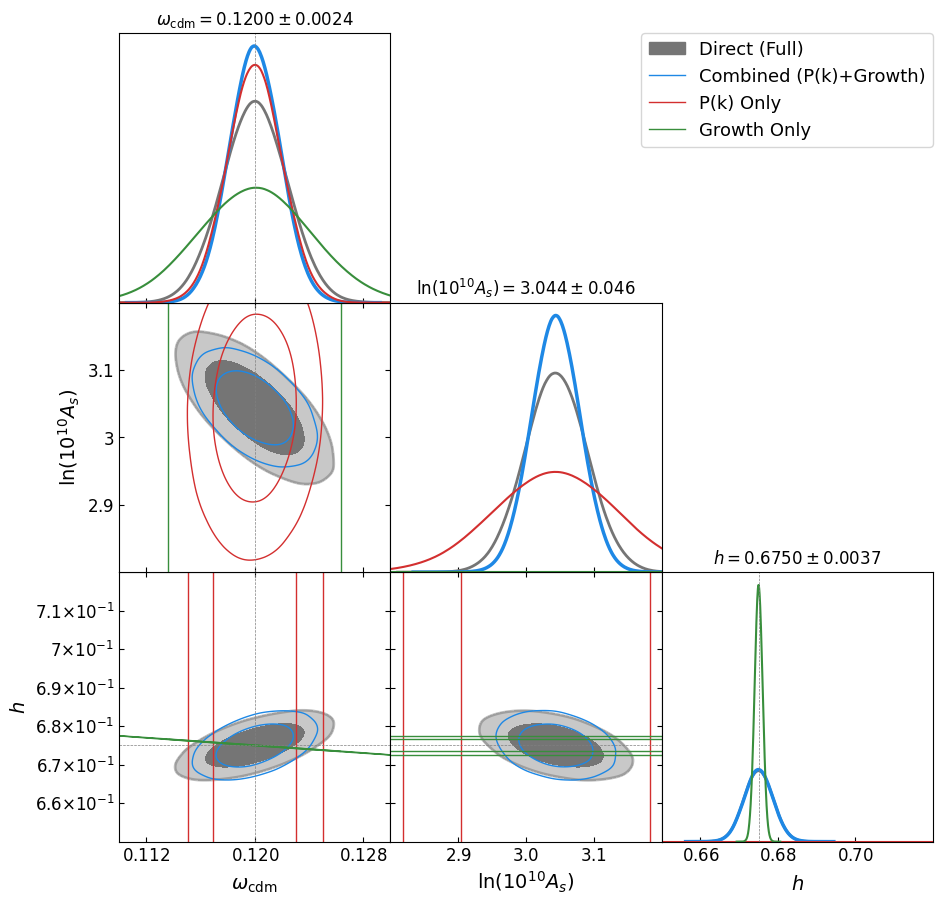

In [57]:
import numpy as np
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND

# 1. Define metadata for GetDist
names = ['omega_cdm', 'logA', 'h']
labels = [r'\omega_{\rm cdm}', r'\ln(10^{10}A_s)', r'h']
fiducial_means = [cosmo_fid['omega_cdm'], cosmo_fid['ln10^{10}A_s'], cosmo_fid['h']]

# 2. Create Gaussian Mixture objects for each Fisher matrix
# Note: F_cosmo_direct_marg_3d and F_cosmo_combined must be 3x3 matrices
# in the order [omega_cdm, logA, h]

# (d) Direct Fisher
dist_direct = GaussianND(fiducial_means, pos_pinv(F_cosmo_direct_marg_3d), 
                         names=names, labels=labels)

# (c) Combined Fisher
dist_combined = GaussianND(fiducial_means, pos_pinv(F_cosmo_combined), 
                           names=names, labels=labels)

# 3. Initialize the triangle plot
g = plots.get_subplot_plotter()

# 4. Plot the comparison
# You can add more distributions to the list as needed
# (a) P(k)-only: only knows about [0, 1] (omega_cdm, logA)
cov_pk_2d = pos_pinv(F_cosmo_from_pk_only_2d)
samples_pk = embed_2d_to_3d(cov_pk_2d , [0, 1], names, labels, 'Pk-only', fiducial_means)

# (b) Growth-only: only knows about [0, 2] (omega_cdm, h)
cov_growth_2d = pos_pinv(F_cosmo_from_growth_only_2d)
samples_growth = embed_2d_to_3d(cov_growth_2d, [0, 2], names, labels, 'Growth-only', fiducial_means)

# (c) & (d) from previous step
samples_direct = fisher_to_samples(fiducial_means, pos_pinv(F_cosmo_direct_marg_3d), names, labels, 'Direct')
samples_combined = fisher_to_samples(fiducial_means, pos_pinv(F_cosmo_combined), names, labels, 'Combined')

# 3. Plotting
import matplotlib.pyplot as plt
from getdist import plots

# 1. Setup high-visibility plot settings
g = plots.get_subplot_plotter(subplot_size=3.5) # Increased size
g.settings.num_plot_contours = 2
g.settings.lw_contour = 2.0
g.settings.axes_fontsize = 12
g.settings.lab_fontsize = 14
g.settings.legend_fontsize = 13
g.settings.alpha_filled_add = 0.2  # Transparency for filled 2D levels

# 2. Define Colors and Styles
# Direct: Gray (Base), Combined: Blue (Comparison), PK: Red, Growth: Green
color_list = ['#757575', '#1E88E5', '#D32F2F', '#388E3C']

# 3. Create the triangle plot
# We use 'filled' to distinguish the "Direct" reference from the components
g.triangle_plot(
    [samples_direct, samples_combined, samples_pk, samples_growth],
    params=names,
    filled=[True, False, False, False], 
    contour_colors=color_list,
    contour_ls=['-', '-', '-', '-'], # All solid for 2D
    line_args=[
        {'color': color_list[0], 'lw': 2, 'ls': '-'},
        {'color': color_list[1], 'lw': 2.5, 'ls': '-'}, # Thicker blue to show overlap
        {'color': color_list[2], 'lw': 1.5, 'ls': '-'},
        {'color': color_list[3], 'lw': 1.5, 'ls': '-'}
    ],
    diag1d_kwargs={'normalized': True},
    legend_labels=['Direct (Full)', 'Combined (P(k)+Growth)', 'P(k) Only', 'Growth Only'],
    param_limits={"h": [0.65, 0.72], "logA": [2.8, 3.2], "omega_cdm": [0.11, 0.13]},
    title_limit=1,
    markers=cosmo_fid
)
